In [1]:
#importing pandas and numpy
import pandas as pd
import numpy as np
# loading dataset
df = pd.read_csv("India Agriculture Crop Production.csv")
df.shape

(345407, 10)

In [2]:
# preview data
df.head()

# column names
df.columns

# data types
df.dtypes

,0
State,object
District,object
Crop,object
Year,object
Season,object
Area,float64
Area Units,object
Production,float64
Production Units,object
Yield,float64


In [3]:
# make column names consistent
df.columns = [col.strip().lower().replace(" ", "_") for col in df.columns]

# clean text columns (remove extra spaces)
df["state"] = df["state"].astype(str).str.strip()
df["district"] = df["district"].astype(str).str.strip()
df["crop"] = df["crop"].astype(str).str.strip()
df["season"] = df["season"].astype(str).str.strip()
df["area_units"] = df["area_units"].astype(str).str.strip()
df["production_units"] = df["production_units"].astype(str).str.strip()


In [23]:
# convert year like '2012-13' to 2012
df["year"] = df["year"].astype(str).str.split("-").str[0]
df["year"] = pd.to_numeric(df["year"], errors="coerce")

In [5]:
# check missing values
df.isnull().sum()

# drop rows with missing key values
df = df.dropna(subset=["state", "district", "crop", "season", "year", "area", "production", "yield"])

df.shape

(340414, 10)

In [6]:
# remove yield outliers using IQR
q1 = df["yield"].quantile(0.25)
q3 = df["yield"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df = df[(df["yield"] >= lower) & (df["yield"] <= upper)]

# remove duplicates
df = df.drop_duplicates().reset_index(drop=True)

df.shape

(289086, 10)

In [7]:
# final dataset check
df.info()
df.head()

# saving cleaned data
df.to_csv("cleaned_crop_data.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 289086 entries, 0 to 289085
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   state             289086 non-null  object 
 1   district          289086 non-null  object 
 2   crop              289086 non-null  object 
 3   year              289086 non-null  int64  
 4   season            289086 non-null  object 
 5   area              289086 non-null  float64
 6   area_units        289086 non-null  object 
 7   production        289086 non-null  float64
 8   production_units  289086 non-null  object 
 9   yield             289086 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 22.1+ MB


In [8]:
# basic stats for numeric columns
df.describe()

# unique counts for key columns
df[["state", "district", "crop", "season"]].nunique()

,0
state,36
district,727
crop,55
season,6


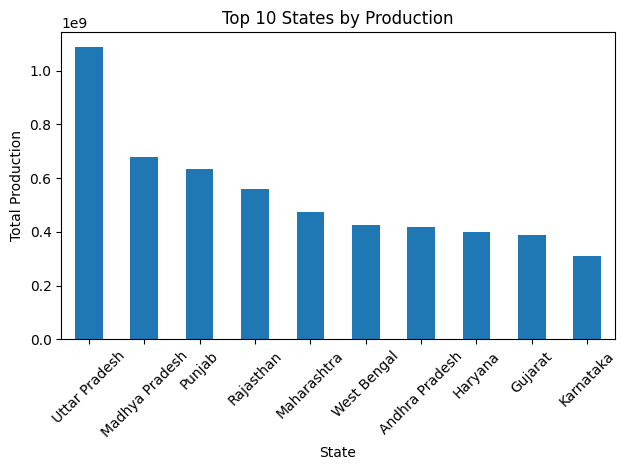

In [9]:
import matplotlib.pyplot as plt

# top states by total production
state_prod = df.groupby("state")["production"].sum().sort_values(ascending=False).head(10)

state_prod.plot(kind="bar")
plt.title("Top 10 States by Production")
plt.xlabel("State")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

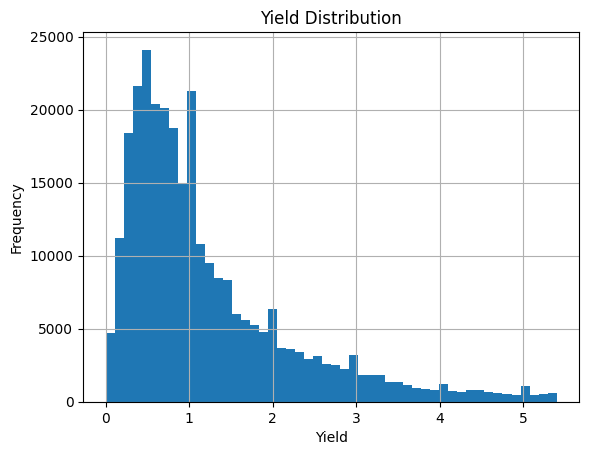

In [10]:
# distribution of yield
df["yield"].hist(bins=50)

plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")
plt.show()

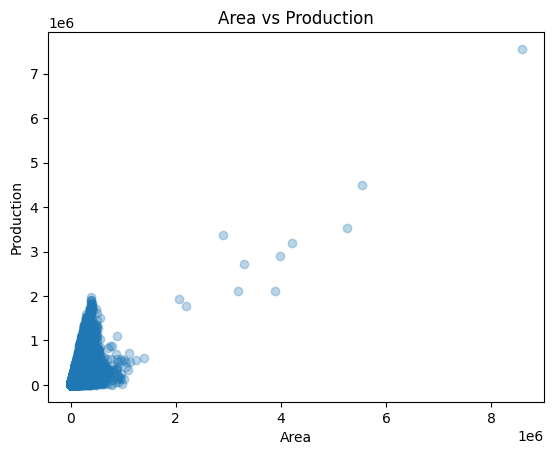

In [11]:
# relationship between area and production
plt.scatter(df["area"], df["production"], alpha=0.3)

plt.title("Area vs Production")
plt.xlabel("Area")
plt.ylabel("Production")
plt.show()

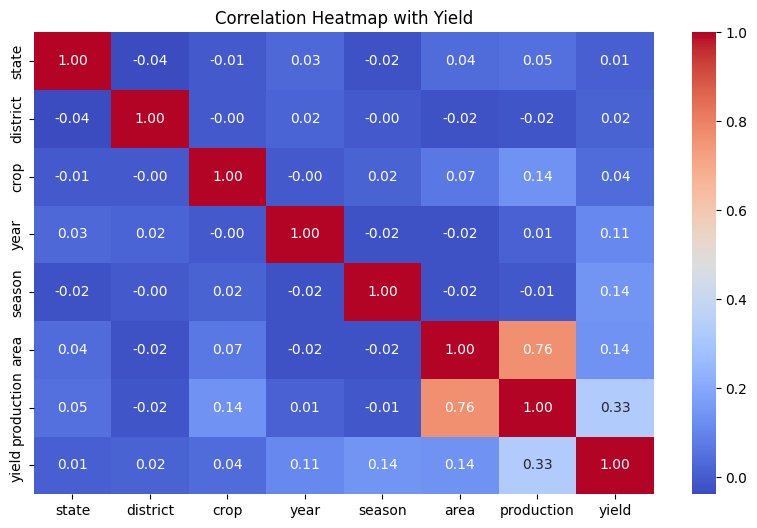

In [12]:
# copy dataset
df_corr = df.copy()

# drop only useless columns
df_corr = df_corr.drop(columns=["area_units", "production_units"])

#encode categorical columns
from sklearn.preprocessing import LabelEncoder

cat_cols = ["state", "district", "season","crop"]

for col in cat_cols:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df_corr[col])

# correlation matrix
corr = df_corr.corr()

# plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap with Yield")
plt.show()

In [13]:
# select input features and target variable
# removing yield (target) and unnecessary unit columns

X = df.drop(columns=["yield", "area_units", "production_units",'production'], errors="ignore")
y = df["yield"]

In [14]:
from sklearn.model_selection import train_test_split

# split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:

from sklearn.preprocessing import OrdinalEncoder

cat_cols = ["state", "district", "crop", "season"]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols])
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Create the Random Forest model
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

# Train the model on the training data
rf.fit(X_train, y_train)

# Make predictions on the test data
rf_pred = rf.predict(X_test)

# Calculate evaluation metrics
r2_rf = r2_score(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)

# Print the model results
print("Random Forest Performance")
print("-------------------------")
print("R2 Score :", round(r2_rf, 4))
print("RMSE     :", round(rmse_rf, 4))
print("MAE      :", round(mae_rf, 4))

Random Forest Performance
-------------------------
R2 Score : 0.8634
RMSE     : 0.3821
MAE      : 0.2147


In [17]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Create the XGBoost model
xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model on the training data
xgb.fit(X_train, y_train)

# Make predictions on the test data
xgb_pred = xgb.predict(X_test)

# Calculate evaluation metrics
r2_xgb = r2_score(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mae_xgb = mean_absolute_error(y_test, xgb_pred)

# Print the model results
print("XGBoost Performance")
print("-------------------")
print("R2 Score :", round(r2_xgb, 4))
print("RMSE     :", round(rmse_xgb, 4))
print("MAE      :", round(mae_xgb, 4))

XGBoost Performance
-------------------
R2 Score : 0.7613
RMSE     : 0.5051
MAE      : 0.3309


In [18]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import numpy as np

# Scale the data for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create the ANN model
ann = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)

# Train the model on the training data
ann.fit(X_train_scaled, y_train)

# Make predictions on the test data
ann_pred = ann.predict(X_test_scaled)

# Calculate evaluation metrics
r2_ann = r2_score(y_test, ann_pred)
rmse_ann = np.sqrt(mean_squared_error(y_test, ann_pred))
mae_ann = mean_absolute_error(y_test, ann_pred)

# Print the model results
print("ANN Performance")
print("----------------")
print("R2 Score :", round(r2_ann, 4))
print("RMSE     :", round(rmse_ann, 4))
print("MAE      :", round(mae_ann, 4))

ANN Performance
----------------
R2 Score : 0.5926
RMSE     : 0.6599
MAE      : 0.4541


In [19]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

# Store train and test results
results = []

# Function to calculate train and test metrics
def evaluate_model(model_name, y_train, train_pred, y_test, test_pred):
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    print(f"{model_name} Performance")
    print("-" * (len(model_name) + 12))
    print("Train R2   :", round(train_r2, 4))
    print("Test R2    :", round(test_r2, 4))
    print("Train RMSE :", round(train_rmse, 4))
    print("Test RMSE  :", round(test_rmse, 4))
    print("Train MAE  :", round(train_mae, 4))
    print("Test MAE   :", round(test_mae, 4))
    print()

    results.append({
        "Model": model_name,
        "Train R2": round(train_r2, 4),
        "Test R2": round(test_r2, 4),
        "Train RMSE": round(train_rmse, 4),
        "Test RMSE": round(test_rmse, 4),
        "Train MAE": round(train_mae, 4),
        "Test MAE": round(test_mae, 4),
        "R2 Gap": round(train_r2 - test_r2, 4)
    })

# Random Forest
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_train_pred = rf.predict(X_train)
rf_test_pred = rf.predict(X_test)
evaluate_model("Random Forest", y_train, rf_train_pred, y_test, rf_test_pred)

# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_train_pred = xgb.predict(X_train)
xgb_test_pred = xgb.predict(X_test)
evaluate_model("XGBoost", y_train, xgb_train_pred, y_test, xgb_test_pred)

# ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ann = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)

ann.fit(X_train_scaled, y_train)
ann_train_pred = ann.predict(X_train_scaled)
ann_test_pred = ann.predict(X_test_scaled)
evaluate_model("ANN", y_train, ann_train_pred, y_test, ann_test_pred)

# Final table
results_df = pd.DataFrame(results)
print("Final Comparison")
print(results_df)

Random Forest Performance
-------------------------
Train R2   : 0.9805
Test R2    : 0.8634
Train RMSE : 0.1435
Test RMSE  : 0.3821
Train MAE  : 0.0798
Test MAE   : 0.2147

XGBoost Performance
-------------------
Train R2   : 0.777
Test R2    : 0.7613
Train RMSE : 0.4852
Test RMSE  : 0.5051
Train MAE  : 0.321
Test MAE   : 0.3309

ANN Performance
---------------
Train R2   : 0.6022
Test R2    : 0.5926
Train RMSE : 0.648
Test RMSE  : 0.6599
Train MAE  : 0.4484
Test MAE   : 0.4541

Final Comparison
           Model  Train R2  Test R2  Train RMSE  Test RMSE  Train MAE  \
0  Random Forest    0.9805   0.8634      0.1435     0.3821     0.0798   
1        XGBoost    0.7770   0.7613      0.4852     0.5051     0.3210   
2            ANN    0.6022   0.5926      0.6480     0.6599     0.4484   

   Test MAE  R2 Gap  
0    0.2147  0.1171  
1    0.3309  0.0157  
2    0.4541  0.0096  


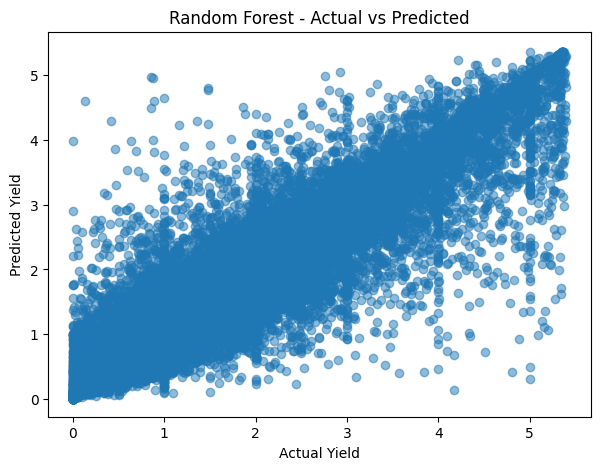

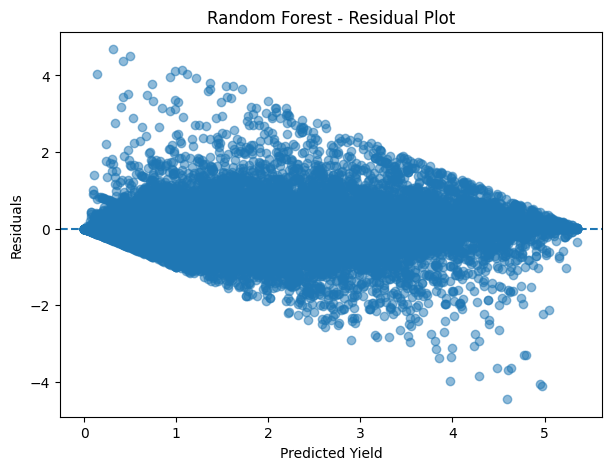

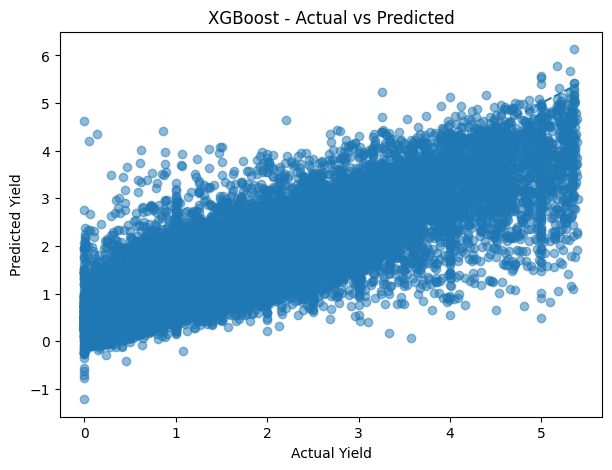

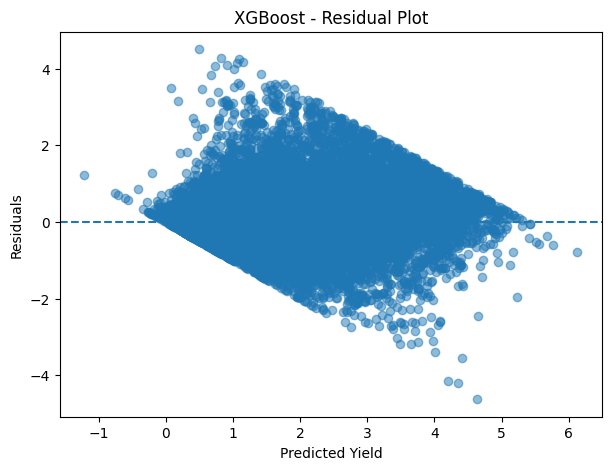

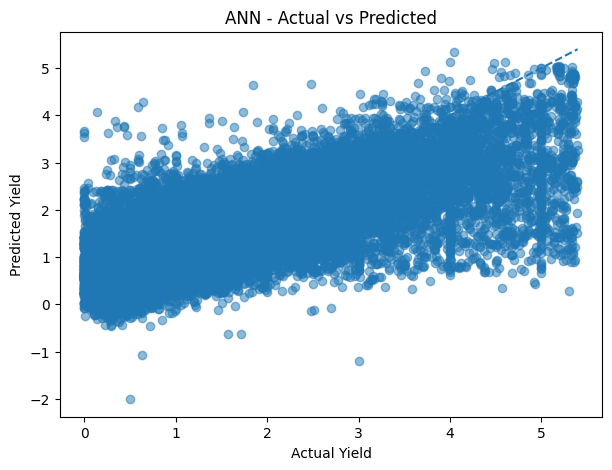

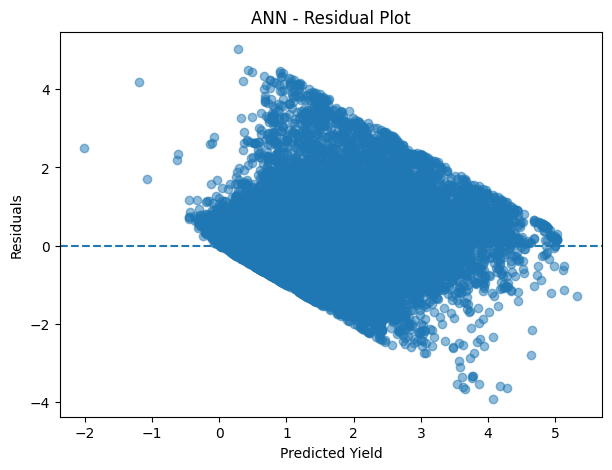

           Model  R2 Score      RMSE       MAE
0  Random Forest  0.863428  0.382078  0.214727
1        XGBoost  0.761299  0.505125  0.330890
2            ANN  0.592580  0.659922  0.454091


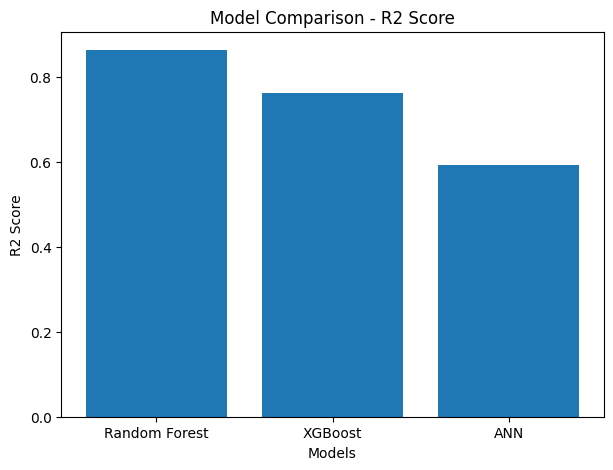

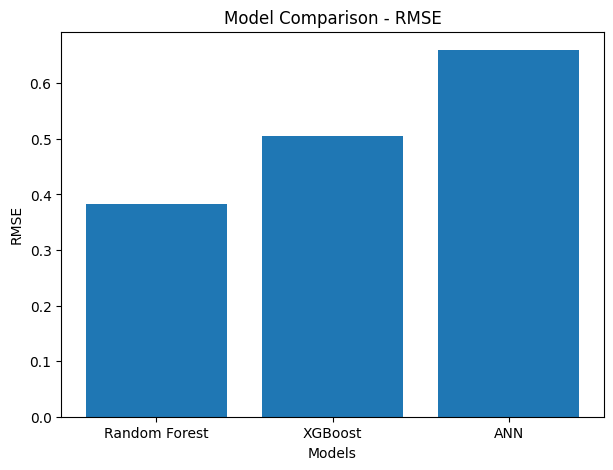

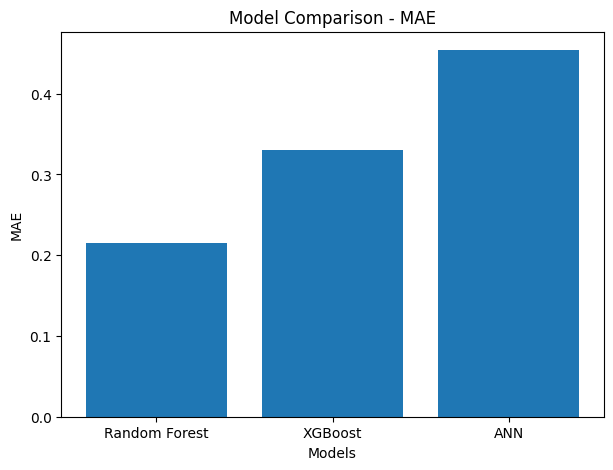

In [20]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Store results for comparison
results = []

# Function to evaluate model and create plots
def evaluate_and_plot(model_name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results.append({
        "Model": model_name,
        "R2 Score": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    # Actual vs Predicted plot
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
    plt.xlabel("Actual Yield")
    plt.ylabel("Predicted Yield")
    plt.title(f"{model_name} - Actual vs Predicted")
    plt.show()

    # Residual plot
    residuals = y_test - y_pred
    plt.figure(figsize=(7, 5))
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(y=0, linestyle='--')
    plt.xlabel("Predicted Yield")
    plt.ylabel("Residuals")
    plt.title(f"{model_name} - Residual Plot")
    plt.show()

# Random Forest
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
evaluate_and_plot("Random Forest", y_test, rf_pred)

# XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
evaluate_and_plot("XGBoost", y_test, xgb_pred)

# ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ann = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42
)
ann.fit(X_train_scaled, y_train)
ann_pred = ann.predict(X_test_scaled)
evaluate_and_plot("ANN", y_test, ann_pred)

# Create comparison table
results_df = pd.DataFrame(results)
print(results_df)

# R2 comparison plot
plt.figure(figsize=(7, 5))
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Comparison - R2 Score")
plt.show()

# RMSE comparison plot
plt.figure(figsize=(7, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")
plt.show()

# MAE comparison plot
plt.figure(figsize=(7, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.xlabel("Models")
plt.ylabel("MAE")
plt.title("Model Comparison - MAE")
plt.show()

In [21]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Function to print the model results
def print_results(model_name, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"{model_name} Performance")
    print("-" * (len(model_name) + 12))
    print("R2 Score :", round(r2, 4))
    print("RMSE     :", round(rmse, 4))
    print("MAE      :", round(mae, 4))
    print()


# Random Forest tuning
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Find the best Random Forest settings
rf_search.fit(X_train, y_train)

# Show the best Random Forest parameters
print("Best Random Forest Parameters:", rf_search.best_params_)

# Predict using the tuned Random Forest model
best_rf = rf_search.best_estimator_
rf_pred = best_rf.predict(X_test)

# Print Random Forest performance
print_results("Random Forest", y_test, rf_pred)


# XGBoost tuning
xgb = XGBRegressor(random_state=42, n_jobs=-1)

xgb_params = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Find the best XGBoost settings
xgb_search.fit(X_train, y_train)

# Show the best XGBoost parameters
print("Best XGBoost Parameters:", xgb_search.best_params_)

# Predict using the tuned XGBoost model
best_xgb = xgb_search.best_estimator_
xgb_pred = best_xgb.predict(X_test)

# Print XGBoost performance
print_results("XGBoost", y_test, xgb_pred)


# Scale the data for ANN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ANN tuning
ann = MLPRegressor(random_state=42, max_iter=300)

ann_params = {
    'hidden_layer_sizes': [(64, 32), (100,), (128, 64), (64, 64)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01, 0.0005],
    'solver': ['adam']
}

ann_search = RandomizedSearchCV(
    estimator=ann,
    param_distributions=ann_params,
    n_iter=6,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Find the best ANN settings
ann_search.fit(X_train_scaled, y_train)

# Show the best ANN parameters
print("Best ANN Parameters:", ann_search.best_params_)

# Predict using the tuned ANN model
best_ann = ann_search.best_estimator_
ann_pred = best_ann.predict(X_test_scaled)

# Print ANN performance
print_results("ANN", y_test, ann_pred)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Random Forest Parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None}
Random Forest Performance
-------------------------
R2 Score : 0.8597
RMSE     : 0.3872
MAE      : 0.2211

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost Parameters: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.1}
XGBoost Performance
-------------------
R2 Score : 0.8385
RMSE     : 0.4155
MAE      : 0.2618

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best ANN Parameters: {'solver': 'adam', 'learning_rate_init': 0.001, 'hidden_layer_sizes': (128, 64), 'activation': 'tanh'}
ANN Performance
---------------
R2 Score : 0.7201
RMSE     : 0.547
MAE      : 0.3674



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


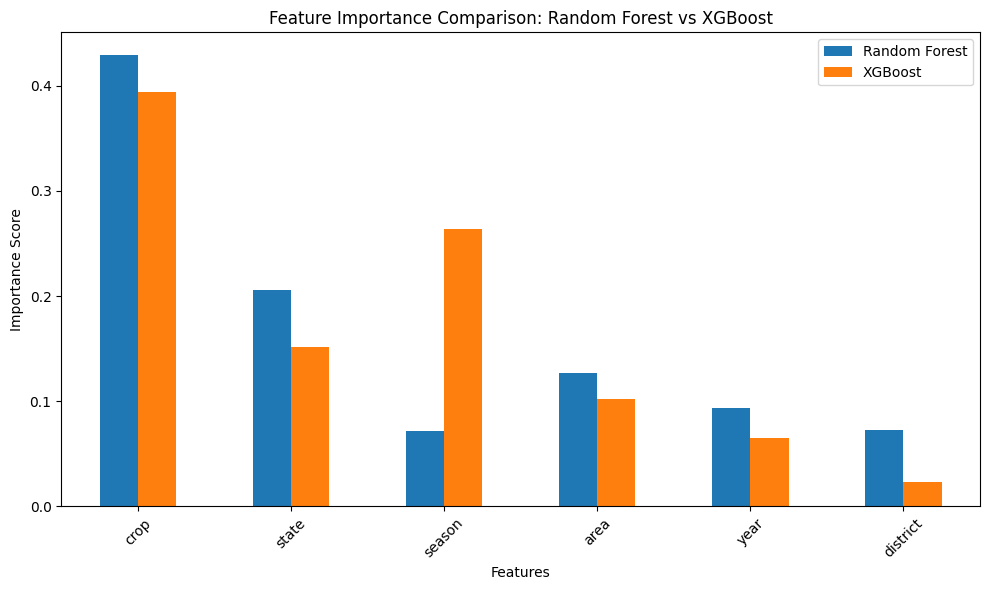

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

# Extract feature importance
rf_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
xgb_importance = pd.Series(xgb.feature_importances_, index=X_train.columns)

# Combine into one dataframe
importance_df = pd.DataFrame({
    "Random Forest": rf_importance,
    "XGBoost": xgb_importance
})

# Sort by average importance
importance_df["Average"] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values("Average", ascending=False).drop(columns="Average")

# Keep top 6 features
top_features = importance_df.head(6)

# Plot both models in one figure
top_features.plot(kind="bar", figsize=(10, 6))
plt.title("Feature Importance Comparison: Random Forest vs XGBoost")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()